In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [13]:
df = pd.read_csv("data/dataset.csv")
df.head()

,text,clean_text,style,tone
0,"The sheer, unadulterated arrogance required to...","the sheer , unadulterated arrogance require to...",academic,aggressive
1,It is entirely baffling how an executive manag...,it be entirely baffle how an executive manager...,business,aggressive
2,Your team has aggressively managed to complete...,your team have aggressively manage to complete...,business,aggressive
3,Synergy is just a fancy word for doing all the...,synergy be just a fancy word for do all the wo...,business,sarcastic
4,Contemporary linguistic theories frequently ex...,contemporary linguistic theory frequently expl...,academic,neutral


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        1000 non-null   str  
 1   clean_text  1000 non-null   str  
 2   style       1000 non-null   str  
 3   tone        1000 non-null   str  
dtypes: str(4)
memory usage: 31.4 KB


In [15]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
academic    200
business    200
informal    200
formal      200
literaly    200
Name: count, dtype: int64


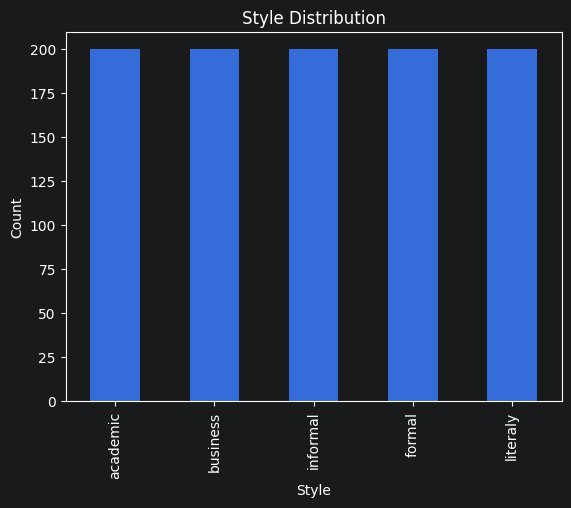

In [16]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
aggressive    200
sarcastic     200
neutral       200
urgent        200
friendly      200
Name: count, dtype: int64


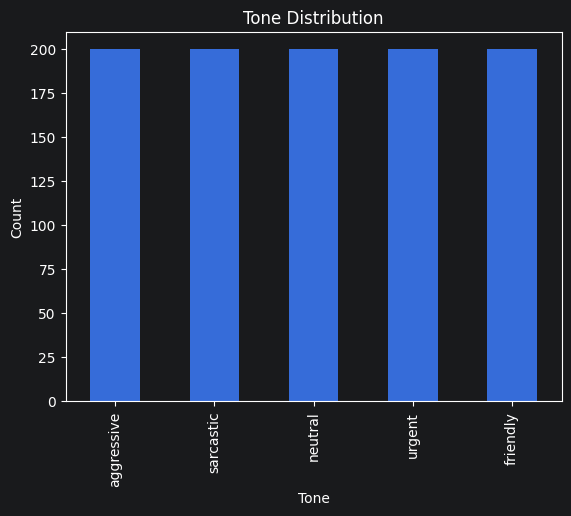

In [17]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          40        40       40         40      40
business          40        40       40         40      40
formal            40        40       40         40      40
informal          40        40       40         40      40
literaly          40        40       40         40      40


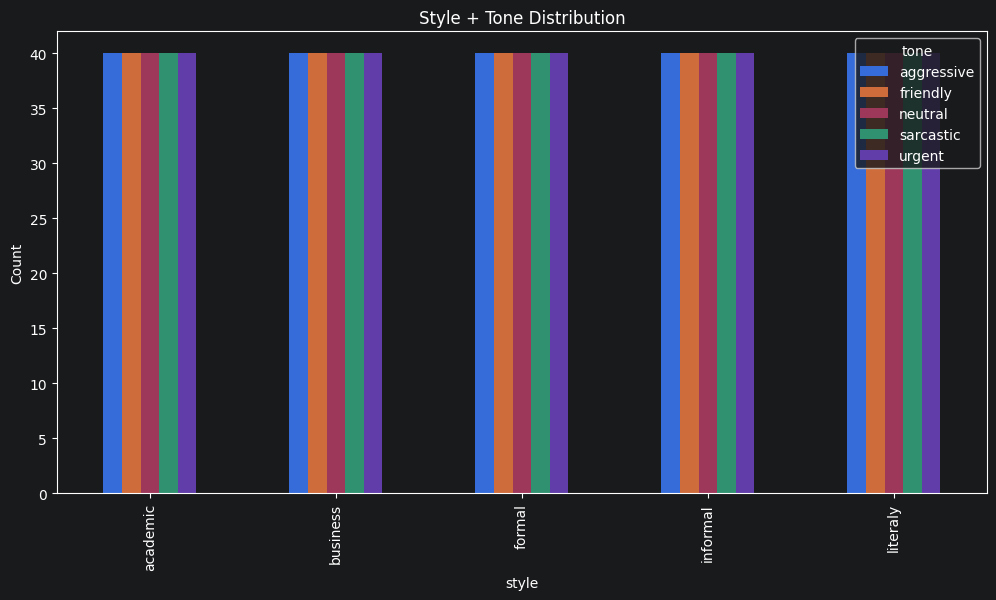

In [18]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [19]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count    1000.000000
mean      399.924000
std       234.083766
min        10.000000
25%       200.000000
50%       399.000000
75%       596.000000
max      1002.000000
Name: text_length, dtype: float64

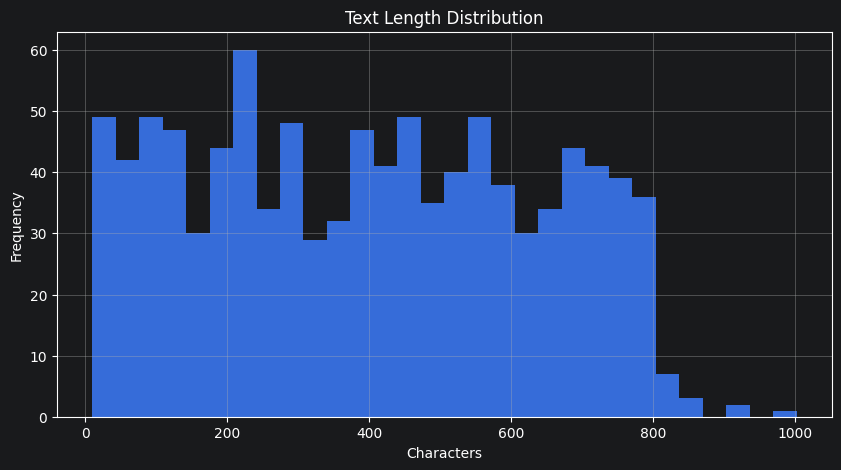

In [20]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

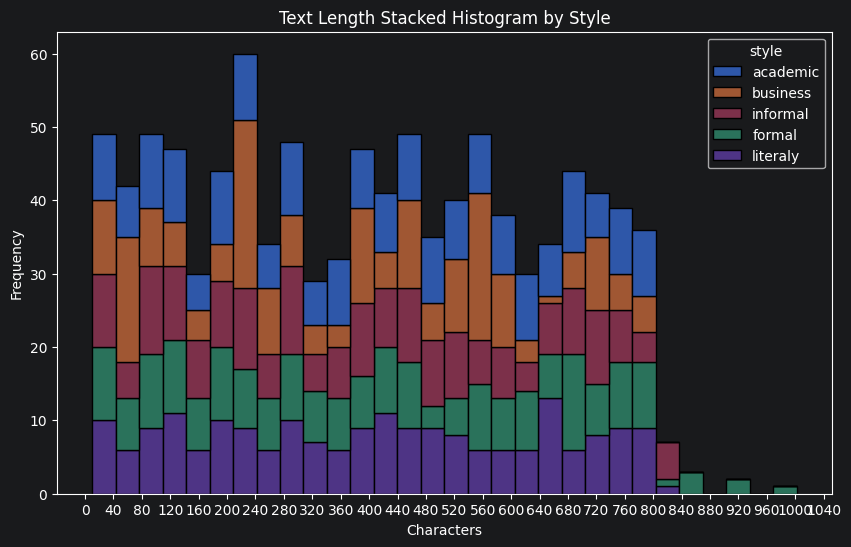

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="style",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))

plt.title("Text Length Stacked Histogram by Style")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

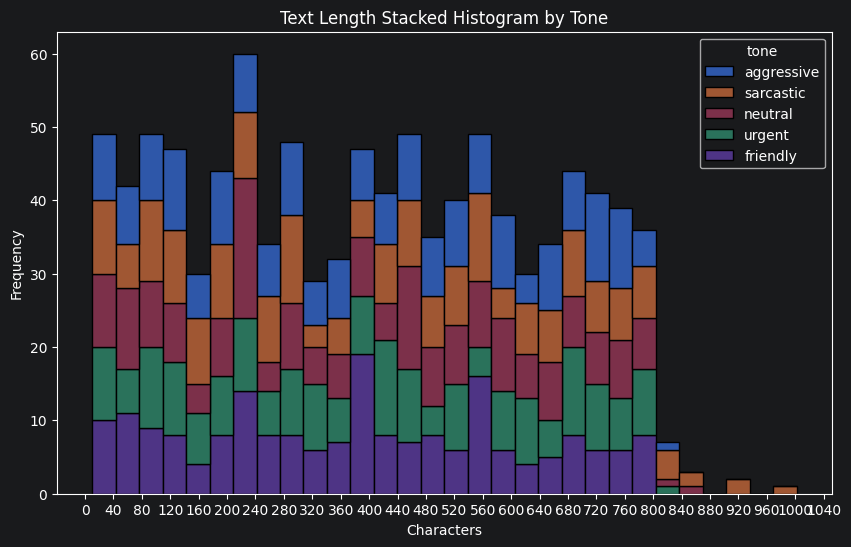

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="tone",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))
plt.title("Text Length Stacked Histogram by Tone")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()